Rodrigo Romay Aba

Ainhoa de Diego Silva

In [1]:
import os
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.layers import Input, Embedding, Dot, Flatten, Dense, Reshape
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.sequence import skipgrams
from sklearn.metrics.pairwise import cosine_similarity
from tensorflow.keras.callbacks import EarlyStopping
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

Lectura del dataset y tokenización

In [2]:
ruta_archivo = os.path.join('datasets', 'game_of_thrones.txt') 

# Leemos el archivo completo
with open(ruta_archivo, 'r', encoding='utf-8') as f:
    texto_corpus = f.read()

print("Entrenando el Tokenizador...")
tokenizer = Tokenizer()
# Keras espera una lista de textos
tokenizer.fit_on_texts([texto_corpus])

# Transformamos todo el texto en una lista plana de IDs numéricos
secuencia_ids = tokenizer.texts_to_sequences([texto_corpus])[0]

# El tamaño del vocabulario (sumamos 1 por el index 0 reservado de Keras)
vocab_size = len(tokenizer.word_index) + 1 
print(f"Tamaño del vocabulario: {vocab_size}")
print(f"Total de palabras en el texto: {len(secuencia_ids)}")

Entrenando el Tokenizador...
Tamaño del vocabulario: 7479
Total de palabras en el texto: 108209


Submuestreo de palabras frecuentes

Descartamos palabras muy frecuentes ("el", "de", "a"...) que aportan poco valor semántico.
Esto reduce la secuencia y por tanto el número de muestras generadas, haciendo
el entrenamiento comparable en tamaño al de CBOW.

In [3]:
def submuestreo(secuencia, t=1e-3):
    """
    Descarta palabras muy frecuentes con probabilidad P(w) = 1 - sqrt(t / f(w))
    donde f(w) es la frecuencia relativa de la palabra en el corpus.
    Fórmula de Mikolov et al. (2013), umbral t=1e-3 por defecto.
    """
    total_words = len(secuencia)

    # Contamos la frecuencia absoluta de cada ID
    conteo = {}
    for word_id in secuencia:
        conteo[word_id] = conteo.get(word_id, 0) + 1

    secuencia_filtrada = []
    for word_id in secuencia:
        freq = conteo[word_id] / total_words
        # Probabilidad de descartar: acotada entre 0 y 1
        prob_descartar = max(0.0, 1.0 - np.sqrt(t / freq))
        if np.random.random() > prob_descartar:
            secuencia_filtrada.append(word_id)

    return secuencia_filtrada

# Usamos la función que ya tienes definida en tu celda 4
print("Aplicando submuestreo para limpiar el texto...")
secuencia_submuestreada = submuestreo(secuencia_ids, t=1e-3)

print(f"Palabras originales: {len(secuencia_ids)}")
print(f"Palabras tras el filtro: {len(secuencia_submuestreada)}")

Aplicando submuestreo para limpiar el texto...
Palabras originales: 108209
Palabras tras el filtro: 72655


Creación de muestras

Generamos pares (central, contexto) con etiqueta 1 (positivo) y pares negativos
con etiqueta 0. Usamos num_negative=2 para mantener un tamaño de dataset
comparable al de CBOW (~100k muestras).

In [4]:
# Configuramos la ventana (3 a la izquierda, 3 a la derecha)
window_size = 6

# Generamos las parejas reales y las inventadas (muestreo negativo)
pairs, labels = skipgrams(secuencia_submuestreada, 
                          vocabulary_size=vocab_size, 
                          window_size=window_size, 
                          negative_samples=4.0, # 4 falsas por cada 1 real
                          seed=42) 

# Las separamos para que la red las entienda
word_target, word_context = zip(*pairs)
word_target = np.array(word_target, dtype="int32")
word_context = np.array(word_context, dtype="int32")
labels = np.array(labels, dtype="int32")

print(f"Parejas generadas tras submuestreo: {len(pairs)}")


Parejas generadas tras submuestreo: 4359090


Definición del modelo Skipgram

In [5]:
embedding_dim = 100 

# Las dos ventanitas de entrada
input_target = Input((1,), name="entrada_palabra_central")
input_context = Input((1,), name="entrada_palabra_contexto")

# El diccionario de vectores (Capa de Embedding)
# Esta es la parte que luego dibujaremos en la gráfica
embedding_layer = Embedding(vocab_size, embedding_dim, name="capa_embedding")

# Pasamos las palabras por el diccionario
target_vector = embedding_layer(input_target)
context_vector = embedding_layer(input_context)

# Multiplicamos los vectores para ver si se parecen
dot_product = Dot(axes=2)([target_vector, context_vector])
dot_product = Flatten()(dot_product)

# Salida: ¿Son amigas (1) o no (0)?
output = Dense(1, activation="sigmoid")(dot_product)

modelo_skipgram = Model(inputs=[input_target, input_context], outputs=output)
modelo_skipgram.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])

modelo_skipgram.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ entrada_palabra_ce… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ entrada_palabra_co… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ capa_embedding      │ (None, 1, 100)    │    747,900 │ entrada_palabra_… │
│ (Embedding)         │                   │            │ entrada_palabra_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot (Dot)           │ (None, 1, 1)      │          0 │ capa_embedding[0… │
│                     │                   │            │ capa_embedding[1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 1)         │          0 │ dot[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │          2 │ flatten[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 747,902 (2.85 MB)

 Trainable params: 747,902 (2.85 MB)

 Non-trainable params: 0 (0.00 B)

Entrenamiento

In [6]:
print("\nIniciando el entrenamiento...")

# Pesos de clase para compensar el desbalance 1 positivo : 2 negativos
class_weight = {0: 1.0, 1: 4.0}

historial = modelo_skipgram.fit(
    x=[word_target, word_context], 
    y=labels, 
    batch_size=1024, # Usamos un número alto para que vaya más rápido
    epochs=8,       # Con 10 épocas la gráfica suele salir mucho mejor
    validation_split=0.1
)


# Extraemos los vectores aprendidos
pesos_embeddings = modelo_skipgram.get_layer('capa_embedding').get_weights()[0]
print(f"\nForma final de la matriz de embeddings: {pesos_embeddings.shape}")


Iniciando el entrenamiento...
Epoch 1/8
3832/3832 ━━━━━━━━━━━━━━━━━━━━ 27s 7ms/step - accuracy: 0.8405 - loss: 0.4255 - val_accuracy: 0.8506 - val_loss: 0.3642
Epoch 2/8
3832/3832 ━━━━━━━━━━━━━━━━━━━━ 24s 6ms/step - accuracy: 0.8589 - loss: 0.3295 - val_accuracy: 0.8601 - val_loss: 0.3170
Epoch 3/8
3832/3832 ━━━━━━━━━━━━━━━━━━━━ 24s 6ms/step - accuracy: 0.8804 - loss: 0.2655 - val_accuracy: 0.8671 - val_loss: 0.2925
Epoch 4/8
3832/3832 ━━━━━━━━━━━━━━━━━━━━ 24s 6ms/step - accuracy: 0.8945 - loss: 0.2331 - val_accuracy: 0.8701 - val_loss: 0.2836
Epoch 5/8
3832/3832 ━━━━━━━━━━━━━━━━━━━━ 25s 6ms/step - accuracy: 0.9008 - loss: 0.2181 - val_accuracy: 0.8714 - val_loss: 0.2800
Epoch 6/8
3832/3832 ━━━━━━━━━━━━━━━━━━━━ 25s 7ms/step - accuracy: 0.9043 - loss: 0.2096 - val_accuracy: 0.8722 - val_loss: 0.2781
Epoch 7/8
3832/3832 ━━━━━━━━━━━━━━━━━━━━ 25s 6ms/step - accuracy: 0.9066 - loss: 0.2039 - val_accuracy: 0.8725 - val_loss: 0.2779
Epoch 8/8
3832/3832 ━━━━━━━━━━━━━━━━━━━━ 25s 7ms/step - acc

Evaluación de similitud semántica

In [7]:
print("\n--- Evaluando Similitud Semántica ---")

# Invertimos el diccionario para buscar palabras a partir de su ID
index_word = {id: palabra for palabra, id in tokenizer.word_index.items()}

def obtener_palabras_similares(palabra_objetivo, matriz_embeddings, top_n=10):
    if palabra_objetivo not in tokenizer.word_index:
        print(f"La palabra '{palabra_objetivo}' no está en el vocabulario.")
        return

    word_id     = tokenizer.word_index[palabra_objetivo]
    word_vector = matriz_embeddings[word_id].reshape(1, -1)

    # Similitud del coseno contra todos los vectores del vocabulario
    similitudes = cosine_similarity(word_vector, matriz_embeddings)[0]
    indices_top = np.argsort(similitudes)[::-1][1:top_n + 1]

    print(f"\nLas {top_n} palabras más similares a '{palabra_objetivo}':")
    for idx in indices_top:
        if idx in index_word:
            print(f" - {index_word[idx]} (Similitud: {similitudes[idx]:.4f})")

palabras_prueba = ["betray", "ambitious", "sword", "wall"]

for palabra in palabras_prueba:
    obtener_palabras_similares(palabra, pesos_embeddings, top_n=10)


--- Evaluando Similitud Semántica ---

Las 10 palabras más similares a 'betray':
 - betrayed (Similitud: 0.4786)
 - flinch (Similitud: 0.3844)
 - even (Similitud: 0.3617)
 - thigh (Similitud: 0.3525)
 - fist (Similitud: 0.3520)
 - hate (Similitud: 0.3333)
 - greatest (Similitud: 0.3234)
 - porther (Similitud: 0.3179)
 - chewed (Similitud: 0.3163)
 - nothing (Similitud: 0.3156)

Las 10 palabras más similares a 'ambitious':
 - manhood (Similitud: 0.4053)
 - enemies (Similitud: 0.3800)
 - ones (Similitud: 0.3713)
 - ill (Similitud: 0.3599)
 - adventures (Similitud: 0.3483)
 - easily (Similitud: 0.3468)
 - ending (Similitud: 0.3449)
 - glamour (Similitud: 0.3382)
 - sweltered (Similitud: 0.3306)
 - endure (Similitud: 0.3279)

Las 10 palabras más similares a 'sword':
 - hilt (Similitud: 0.4570)
 - boy (Similitud: 0.4324)
 - steel (Similitud: 0.4285)
 - he (Similitud: 0.4243)
 - arya (Similitud: 0.4201)
 - when (Similitud: 0.4186)
 - be (Similitud: 0.4183)
 - nerveless (Similitud: 0.4163)
 

Comprobación de embeddings degenerados

In [8]:
print("\n--- Comprobación de Embeddings Degenerados ---")

std_dev = np.std(pesos_embeddings)
print(f"Desviación típica de los embeddings: {std_dev:.4f}")

if std_dev < 0.05:
    print("[FAIL] Cuidado: Los embeddings podrían estar degenerados (colapsados en la misma región).")
else:
    print("[OK] Embeddings saludables. Existe una dispersión correcta en el espacio vectorial.")


--- Comprobación de Embeddings Degenerados ---
Desviación típica de los embeddings: 0.2375
[OK] Embeddings saludables. Existe una dispersión correcta en el espacio vectorial.


Visualización t-SNE


--- Generando Visualización t-SNE ---
Se han cargado 52 palabras para visualizar.


c:\Users\lovea\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Gráfico guardado como: tsne_skipgram.png


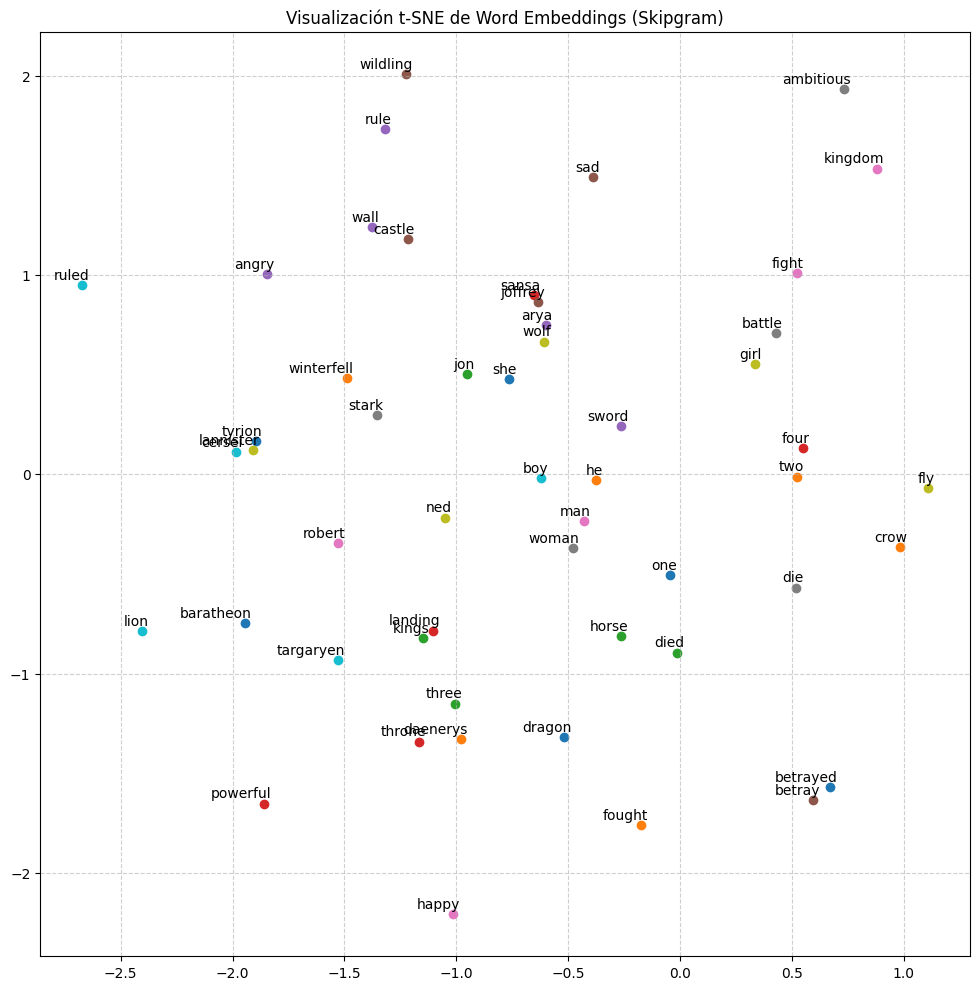

In [9]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize

print("\n--- Generando Visualización t-SNE ---")
pesos_normalizados = normalize(pesos_embeddings)

def visualize_tsne_embeddings(words, embeddings, word_index, filename=None):
    words_present = [w for w in words if w in word_index]

    if not words_present:
        print("Ninguna de las palabras objetivo está en el vocabulario.")
        return

    indices             = [word_index[word] for word in words_present]
    selected_embeddings = embeddings[indices]

    #perplexity = min(5, len(words_present) - 1)

    # Sube la perplexity a 25 o 30 y añade early_exaggeration
    tsne = TSNE(
    n_components=2, 
    perplexity=30,           # Antes tendrías 5 o 10, súbelo a 25
    early_exaggeration=15,   # Esto obliga a que se formen grupos apretados al principio
    learning_rate='auto', 
    init='pca',              # Usar PCA como inicio ayuda a que no sea tan caótico
    n_iter=2000,             # Dale más tiempo para recolocarse
    random_state=42
        )
    
    reduced_embeddings = tsne.fit_transform(selected_embeddings)

    plt.figure(figsize=(12, 12))
    for i, word in enumerate(words_present):
        plt.scatter(reduced_embeddings[i, 0], reduced_embeddings[i, 1], marker='o')
        plt.annotate(word,
                     xy=(reduced_embeddings[i, 0], reduced_embeddings[i, 1]),
                     xytext=(5, 2), textcoords='offset points',
                     ha='right', va='bottom')

    plt.title("Visualización t-SNE de Word Embeddings (Skipgram)")
    plt.grid(True, linestyle='--', alpha=0.6)

    if filename:
        plt.savefig(filename)
        print(f"Gráfico guardado como: {filename}")
    else:
        plt.show()

ruta_target = os.path.join('mats', 'target_words_game_of_thrones.txt')

try:
    with open(ruta_target, 'r', encoding='utf-8') as f:
        palabras_objetivo = [linea.strip().lower() for linea in f.readlines() if linea.strip()]

    print(f"Se han cargado {len(palabras_objetivo)} palabras para visualizar.")
    visualize_tsne_embeddings(palabras_objetivo, pesos_normalizados, tokenizer.word_index, filename="tsne_skipgram.png")

except FileNotFoundError:
    print(f"No se ha encontrado el archivo en la ruta: {ruta_target}")